# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en el Classroom como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algoritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.utils import img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os

In [2]:
IMAGE_WIDTH=32
IMAGE_HEIGHT=32
IMAGE_CHANNELS=3
IMAGE_SIZE=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)
BATCH_SIZE = 32
EPOCHS = 30

## 1. Cargar Imagenes

In [3]:
ROOT_PATH = "C:\\Users\\rns_2\\Desktop\\Datasets\\clasificador_paisajes"
TRAIN_PATH = ROOT_PATH + "\\seg_train\\"
TEST_PATH = ROOT_PATH + "\\seg_test\\"

In [4]:
filenames = []
categories = []

# Recorremos las 6 carpetas (buildings, forest, glacier...)
for category in os.listdir(TRAIN_PATH):
    carpeta_categoria = os.path.join(TRAIN_PATH, category)
    
    # Recorremos las imágenes dentro de cada carpeta
    for filename in os.listdir(carpeta_categoria):
        filenames.append(category + "_" + filename)  # ruta completa
        categories.append(category)  # nombre de la carpeta = etiqueta

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
print(df.head())
print(df['category'].value_counts())

(14034, 2)
              filename   category
0      buildings_0.jpg  buildings
1  buildings_10006.jpg  buildings
2   buildings_1001.jpg  buildings
3  buildings_10014.jpg  buildings
4  buildings_10018.jpg  buildings
category
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191
Name: count, dtype: int64


In [5]:
df

,filename,category
0,buildings_0.jpg,buildings
1,buildings_10006.jpg,buildings
2,buildings_1001.jpg,buildings
3,buildings_10014.jpg,buildings
4,buildings_10018.jpg,buildings
...,...,...
14029,street_9961.jpg,street
14030,street_9967.jpg,street
14031,street_9978.jpg,street
14032,street_9989.jpg,street


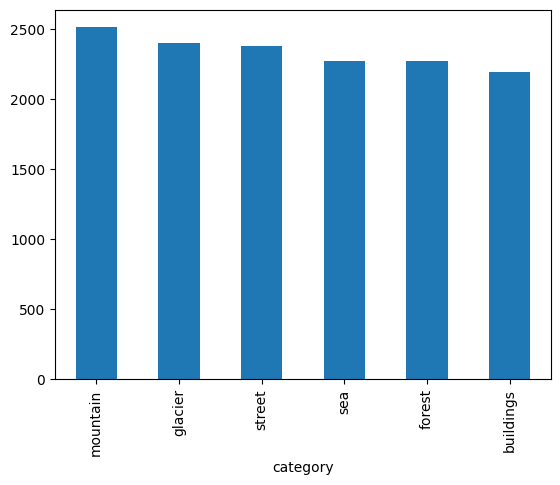

In [6]:
df['category'].value_counts().plot.bar();

## 2. Cargar Imagenes

In [7]:
imagenes = []

for i, row in df.iterrows():
    nombre_original = row['filename'].replace(row['category'] + "_", "")
    ruta = os.path.join(TRAIN_PATH, row['category'], nombre_original)
    
    img = load_img(ruta, target_size=(IMAGE_WIDTH, IMAGE_HEIGHT))
    img_array = img_to_array(img)
    imagenes.append(img_array)

X_train = np.array(imagenes)
y_train = np.array(df['category'])

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}")

imagenes

Shape X_train: (14034, 32, 32, 3)
Shape y_train: (14034,)


[array([[[247., 247., 245.],
         [247., 249., 246.],
         [247., 249., 246.],
         ...,
         [250., 250., 248.],
         [250., 250., 250.],
         [248., 248., 248.]],
 
        [[247., 249., 246.],
         [247., 249., 246.],
         [247., 249., 246.],
         ...,
         [253., 253., 253.],
         [251., 251., 251.],
         [250., 250., 250.]],
 
        [[248., 250., 249.],
         [247., 249., 248.],
         [248., 250., 249.],
         ...,
         [253., 253., 253.],
         [252., 252., 252.],
         [252., 252., 252.]],
 
        ...,
 
        [[ 76.,  75.,  73.],
         [ 98.,  97.,  95.],
         [ 30.,  29.,  27.],
         ...,
         [ 23.,  19.,  16.],
         [ 37.,  33.,  30.],
         [ 91.,  86.,  83.]],
 
        [[ 72.,  68.,  67.],
         [ 62.,  58.,  57.],
         [ 99.,  95.,  94.],
         ...,
         [ 86.,  81.,  78.],
         [ 63.,  58.,  54.],
         [ 74.,  69.,  66.]],
 
        [[ 49.,  48.,  46.],
 

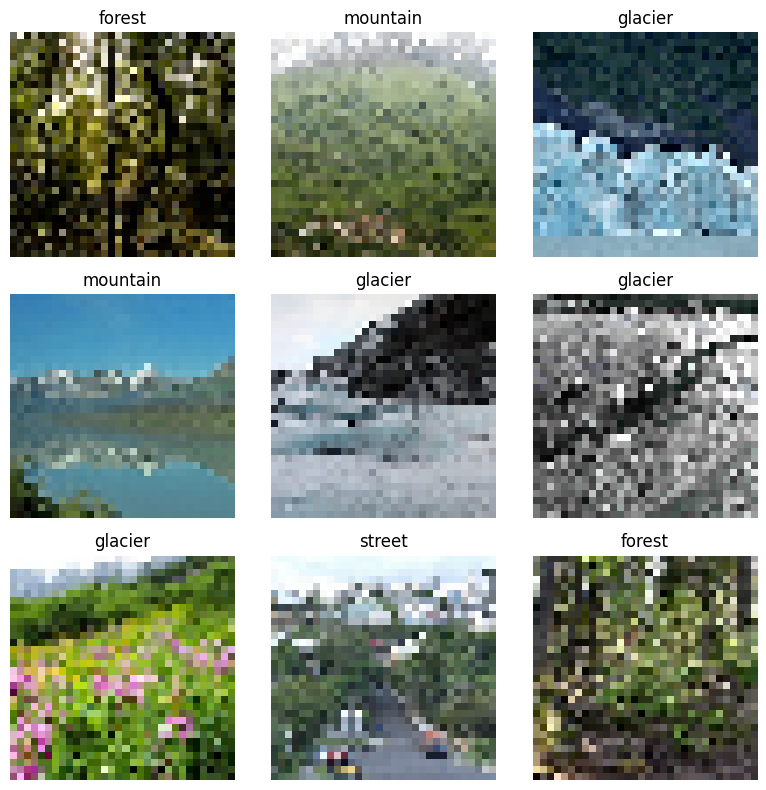

In [8]:
# Mostramos 9 imágenes aleatorias con su etiqueta
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flatten():
    i = random.randint(0, len(X_train) - 1)
    ax.imshow(X_train[i].astype('uint8'))  # uint8 para que matplotlib muestre los colores bien
    ax.set_title(y_train[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Normalizar

In [9]:
import cv2
from skimage.io import imread

def read_data(path, im_size):
    X = []
    Y = []

    # Iteramos sobre las 6 carpetas (buildings, forest, glacier...)
    for category in os.listdir(path):
        carpeta_categoria = os.path.join(path, category)

        # Iteramos sobre las imágenes dentro de cada carpeta
        for filename in os.listdir(carpeta_categoria):
            ruta = os.path.join(carpeta_categoria, filename)

            image = imread(ruta)
            smallimage = cv2.resize(image, (im_size, im_size))

            X.append(smallimage)
            
            category = filename.split('_')[0]
        # Miro si es perro y gato para guardar en Y
            if category == 'buildings':
                Y.append(1)
            elif category == 'forest':
                Y.append(2)
            elif category == 'glacier':
                Y.append(3)
            elif category == 'mountain':
                Y.append(4)
            elif category == 'sea':
                Y.append(5)
            elif category == 'street':
                Y.append(6)
            

    return np.array(X), np.array(Y)


X_train, y_train = read_data(TRAIN_PATH, IMAGE_WIDTH)
X_test, y_test   = read_data(TEST_PATH,  IMAGE_WIDTH)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test:  {X_test.shape}")

Shape X_train: (14034, 32, 32, 3)
Shape X_test:  (3000, 32, 32, 3)


In [10]:
#Ahroa Normalizamos los datos dividiendo por 255 (valor máximo de un pixel)
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"Min: {X_train.min()} | Max: {X_train.max()}")

Min: 0.0 | Max: 1.0


## 4. Construir el modelo

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential([
    # Bloque 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS)),
    MaxPooling2D(2, 2),

    # Bloque 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    # Fully connected
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')  # 6 categorías
])

model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

c:\Users\rns_2\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Entrenar
history = model.fit(X_train, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=0.2)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 11227
'y' sizes: 0
